In [18]:
#import libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [19]:
#Check TensorFlow version and GPU availability
print("TensorFlow Version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("GPU is available")
else:
    print("GPU is not available, but the code can still run on CPU")

TensorFlow Version: 2.20.0
GPU is available


In [20]:
#Load Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


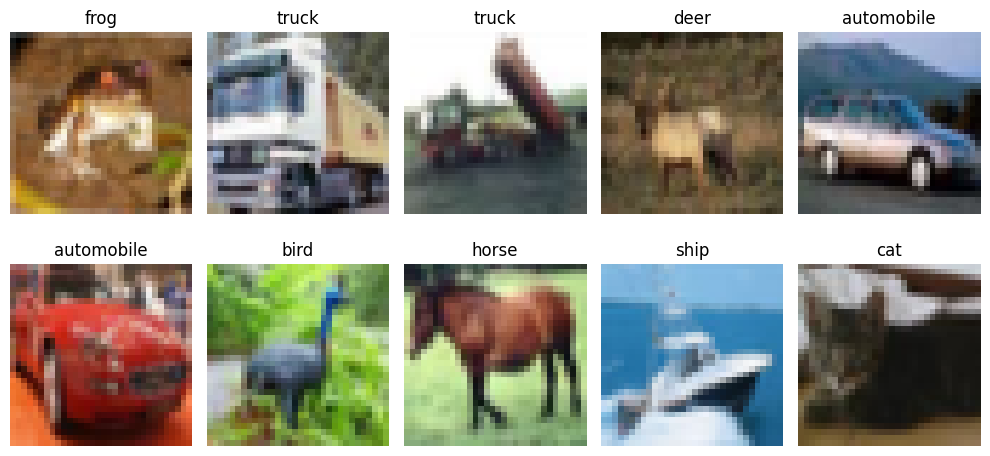

In [21]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [22]:
#Preprocessing
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (50000, 32, 32, 3)
Testing data shape: (10000, 32, 32, 3)


In [23]:
#Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
])

In [24]:
#Build CNN Model
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [26]:
#Train
history = model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(x_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.3030 - loss: 1.8762 - val_accuracy: 0.4197 - val_loss: 1.6418
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.3973 - loss: 1.6404 - val_accuracy: 0.4683 - val_loss: 1.4906
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.4381 - loss: 1.5455 - val_accuracy: 0.4970 - val_loss: 1.3936
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.4684 - loss: 1.4782 - val_accuracy: 0.5239 - val_loss: 1.2954
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4877 - loss: 1.4252 - val_accuracy: 0.5565 - val_loss: 1.2286
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5047 - loss: 1.3870 - val_accuracy: 0.5558 - val_loss: 1.2409
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.5195 - loss: 1.3579 - val_accuracy: 0.5474 - val_loss: 1.3081
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.5317 - loss: 1.3295 - val_accuracy:

In [27]:
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 1.0317
Test Accuracy: 0.6441


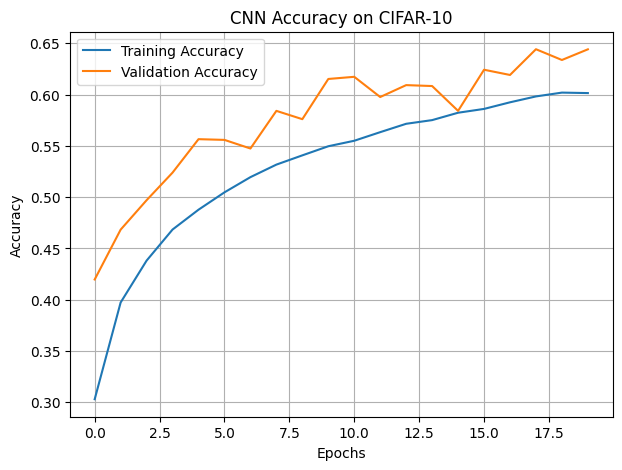

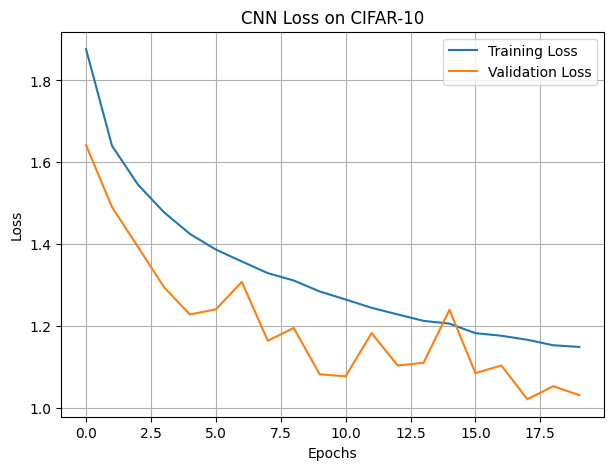

In [28]:
#Plotting
plt.figure(figsize=(7, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy on CIFAR-10")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss on CIFAR-10")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
predictions = model.predict(x_test)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 1000x1000 with 0 Axes>

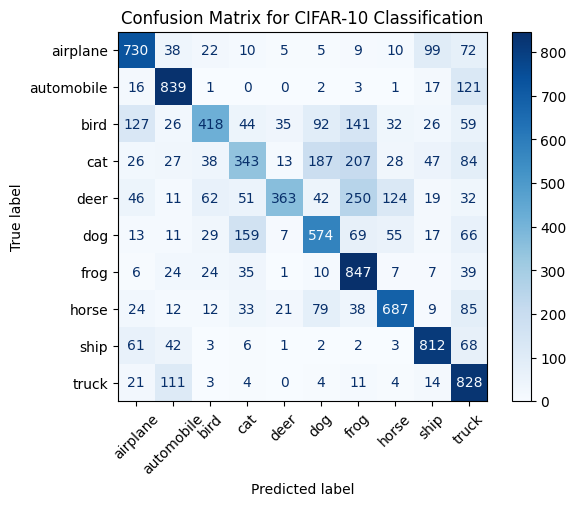

In [30]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
display.plot(cmap="Blues", xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix for CIFAR-10 Classification")
plt.show()

In [31]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.68      0.73      0.71      1000
  automobile       0.74      0.84      0.78      1000
        bird       0.68      0.42      0.52      1000
         cat       0.50      0.34      0.41      1000
        deer       0.81      0.36      0.50      1000
         dog       0.58      0.57      0.57      1000
        frog       0.54      0.85      0.66      1000
       horse       0.72      0.69      0.70      1000
        ship       0.76      0.81      0.79      1000
       truck       0.57      0.83      0.67      1000

    accuracy                           0.64     10000
   macro avg       0.66      0.64      0.63     10000
weighted avg       0.66      0.64      0.63     10000



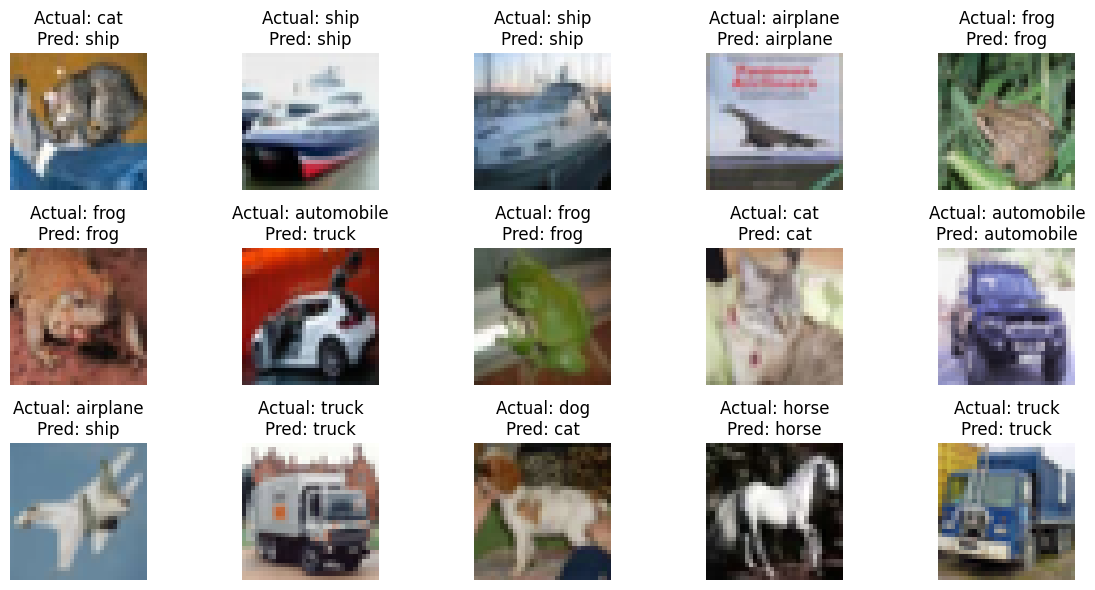

In [32]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i])

    actual = class_names[y_true[i]]
    predicted = class_names[y_pred[i]]

    plt.title(f"Actual: {actual}\nPred: {predicted}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
model.save("cifar10_cnn_model.keras")
print("Model saved successfully")

Model saved successfully
